<a href="https://colab.research.google.com/github/AngeloSorte/lunar-martian-seismic-prediction/blob/angelosorte.github.io/Lunar_%26_Martian_Seismic_Activity_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.1799 - val_loss: 0.0060
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0046 - val_loss: 0.0033
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0031 - val_loss: 0.0029
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0024 - val_loss: 0.0026
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


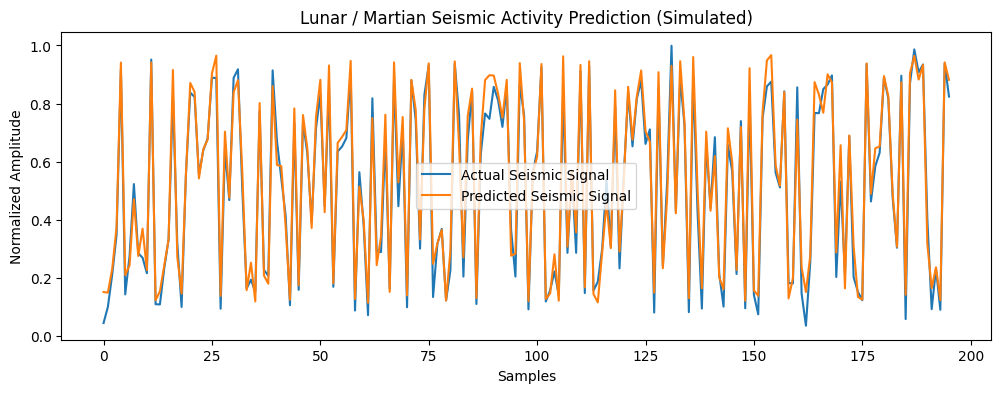

Predicted high seismic events at indices: [ 4 11 16 20 21 23 24 25 26 28] ...


In [ ]:
# ==========================================================
# Lunar & Martian Seismic Activity Prediction
# Simulated Seismometer Data (Colab-ready)
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten

# 1️⃣ Simulate seismic signal data (1000 hours)
# Parameters: amplitude (m/s^2), noise
np.random.seed(42)
time = np.arange(1000)
amplitude = 0.5*np.sin(0.02*time) + 0.05*np.random.randn(1000)  # simulated seismic signal
data = amplitude.reshape(-1,1)

# 2️⃣ Normalize features
scaler = MinMaxScaler()
data_norm = scaler.fit_transform(data)

# 3️⃣ Create LSTM sequences (last 24 hours -> next hour)
SEQ_LENGTH = 24
def create_sequences(data, seq_length=SEQ_LENGTH):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(data_norm)

# 4️⃣ Train / validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5️⃣ Define LSTM model for seismic prediction
model = Sequential([
    LSTM(50, input_shape=(SEQ_LENGTH, X.shape[2])),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# 6️⃣ Train model
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=5, batch_size=16, verbose=1)

# 7️⃣ Predict next seismic amplitude
preds = model.predict(X_val)

# 8️⃣ Visualize prediction vs real seismic signal
plt.figure(figsize=(12,4))
plt.plot(y_val[:200], label='Actual Seismic Signal')
plt.plot(preds[:200], label='Predicted Seismic Signal')
plt.title("Lunar / Martian Seismic Activity Prediction (Simulated)")
plt.xlabel("Samples")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.show()

# 9️⃣ Optional: simple event detection
threshold = 0.6  # normalized amplitude threshold
events = np.where(preds > threshold)[0]
print(f"Predicted high seismic events at indices: {events[:10]} ...")